# Customer Support

Here, we show an example of building a customer support chatbot.

This customer support chatbot interacts with SQL database to answer questions.
We will use a mock SQL database to get started: the [Chinook](https://www.sqlitetutorial.net/sqlite-sample-database/) database.
This database is about sales from a music store: what songs and albums exists, customer orders, things like that.

This chatbot has two different states: 
1. Music: the user can inquire about different songs and albums present in the store
2. Account: the user can ask questions about their account

Under the hood, this is handled by two separate agents. 
Each has a specific prompt and tools related to their objective. 
There is also a generic agent who is responsible for routing between these two agents as needed.

In [163]:
%pip install -U langgraph langchain-openai langchain-community scikit-learn langgraph-checkpoint-sqlite python-dotenv

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [164]:
from dotenv import load_dotenv

load_dotenv()

True

## Load the data

In [165]:
from langchain_community.utilities.sql_database import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///chinook.db")
print(db.get_usable_table_names())
# print(db.run(f"SELECT * FROM customers WHERE CustomerId = 1"))
# print(db.run(f"SELECT * FROM customers WHERE CustomerId = 1 AND FirstName = 'Luís' AND LastName = 'Gonçalves'"))


['albums', 'artists', 'customers', 'employees', 'genres', 'invoice_items', 'invoices', 'media_types', 'playlist_track', 'playlists', 'sqlite_sequence', 'sqlite_stat1', 'tracks']


## Load an LLM

We will load a language model to use.
For this demo we will use OpenAI.

In [166]:
from langchain_openai import ChatOpenAI

# We will set streaming=True so that we can stream tokens
# See the streaming section for more information on this.
model = ChatOpenAI(temperature=0, streaming=True, model="gpt-4-turbo-preview")

## Load Other Modules

Load other modules we will use.

All of the tools our agents will use will be custom tools. As such, we will use the `@tool` decorator to create custom tools.

We will pass in messages to the agent, so we load `HumanMessage` and `SystemMessage`

In [167]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage

## Define the Customer Agent

This agent is responsible for looking up customer information.
It will have a specific prompt as well a specific tool to look up information about that customer (after asking for their user id).

In [168]:
# This tool is given to the agent to look up information about a customer
@tool
def get_customer_info(customer_id: int, first_name: str, last_name: str):
    """
    Retrieves customer information from the database based on Customer ID, First Name, and Last Name.

    Args:
        customer_id (int): The unique ID of the customer.
        first_name (str): The first name of the customer.
        last_name (str): The last name of the customer.

    Returns:
        dict: A dictionary containing customer information, or an error message.
    """
    # Ensure all required parameters are provided
    if not customer_id or not first_name or not last_name:
        return {"error": "Customer ID, First Name, and Last Name are required."}

    query = """
        SELECT * FROM customers
        WHERE CustomerId = %s AND FirstName = '%s' AND LastName = '%s'
    """
    # return db.run(f"SELECT * FROM customers WHERE CustomerID = {customer_id}")
    # print("\n")
    # print("query is %s" % query % (customer_id, first_name, last_name))
    # print("\n")
    try:
        return db.run(query % (customer_id, first_name, last_name))
    except Exception as e:
        return {"error": "Could not find customer with  CustomerId = %s AND FirstName = '%s' AND LastName = '%s'" % (customer_id, first_name, last_name)}


In [169]:
# This tools is given to the agent to update information about a customer
@tool
def update_customer_info(customer_id: int, updates: dict):
    """
    Updates customer information in the database based on Customer ID.

    Args:
        customer_id (int): The ID of the customer to update.
        updates (dict): A dictionary of column-value pairs to update. Valid columns are: FirstName, LastName, Company, Address, City, State, Country, PostalCode, Phone, Fax, Email.

    Returns:
        dict: A success or failure message.
    """
    # Validate input
    if not customer_id or not isinstance(updates, dict) or len(updates) == 0:
        return {"error": "Customer ID and at least one update field are required."}

    # Dynamically construct the SET clause for the SQL query
    set_clause = ", ".join(f"{col} = :{col}" for col in updates.keys())

    # Construct the SQL query
    query = f"""
        UPDATE customers
        SET {set_clause}
        WHERE CustomerId = :customer_id
    """

    # Add the customer_id to the parameters
    parameters = {**updates, "customer_id": customer_id}
    
    try:
        return db.run(query, parameters=parameters)
    except Exception as e:
        return {"error": f"Error updating customer info: {e}"}

In [190]:
customer_prompt = """Your job is to help a user update their profile.

You only have certain tools you can use. These tools require specific input. If you don't know the required input, then ask the user for it.

If you are unable to help the user, you can """

def get_customer_messages(messages):
    return [SystemMessage(content=customer_prompt)] + messages

customer_chain = get_customer_messages | model.bind_tools([get_customer_info, update_customer_info])

## Define the Music Agent

This agent is responsible for figuring out information about music. To do that, we will create a prompt and various tools for looking up information about music

First, we will create indexes for looking up artists and track names.
This will allow us to look up artists and tracks without having to spell their names exactly right.

In [171]:
from langchain_community.vectorstores import SKLearnVectorStore
from langchain_openai import OpenAIEmbeddings

artists = db._execute("select * from artists")
songs = db._execute("select * from tracks")
artist_retriever = SKLearnVectorStore.from_texts(
    [a['Name'] for a in artists],
    OpenAIEmbeddings(), 
    metadatas=artists
).as_retriever()
song_retriever = SKLearnVectorStore.from_texts(
    [a['Name'] for a in songs],
    OpenAIEmbeddings(), 
    metadatas=songs
).as_retriever()

First, let's create a tool for getting albums by artist.

In [172]:
@tool
def get_albums_by_artist(artist):
    """Get albums by an artist (or similar artists)."""
    docs = artist_retriever.get_relevant_documents(artist)
    artist_ids = ", ".join([str(d.metadata['ArtistId']) for d in docs])
    return db.run(f"SELECT Title, Name FROM albums LEFT JOIN artists ON albums.ArtistId = artists.ArtistId WHERE albums.ArtistId in ({artist_ids});", include_columns=True)

Next, lets create a tool for getting tracks by an artist

In [173]:
@tool
def get_tracks_by_artist(artist):
    """Get songs by an artist (or similar artists)."""
    docs = artist_retriever.get_relevant_documents(artist)
    artist_ids = ", ".join([str(d.metadata['ArtistId']) for d in docs])
    return db.run(f"SELECT tracks.Name as SongName, artists.Name as ArtistName FROM albums LEFT JOIN artists ON albums.ArtistId = artists.ArtistId LEFT JOIN tracks ON tracks.AlbumId = albums.AlbumId WHERE albums.ArtistId in ({artist_ids});", include_columns=True)

Finally, let's create a tool for looking up songs by their name.

In [174]:
@tool
def check_for_songs(song_title):
    """Check if a song exists by its name."""
    return song_retriever.get_relevant_documents(song_title)

Create the chain to call the relevant tools

In [175]:
song_system_message = """Your job is to help a customer find any songs they are looking for. 

You only have certain tools you can use. If a customer asks you to look something up that you don't know how, politely tell them what you can help with.

When looking up artists and songs, sometimes the artist/song will not be found. In that case, the tools will return information \
on simliar songs and artists. This is intentional, it is not the tool messing up."""
def get_song_messages(messages):
    return [SystemMessage(content=song_system_message)] + messages

song_recc_chain = get_song_messages | model.bind_tools([get_albums_by_artist, get_tracks_by_artist, check_for_songs])

In [176]:
msgs = [HumanMessage(content="hi! can you help me find songs by amy whinehouse?")]
song_recc_chain.invoke(msgs)
song_recc_chain

RunnableLambda(get_song_messages)
| RunnableBinding(bound=ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x3303121c0>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x1211a52e0>, root_client=<openai.OpenAI object at 0x3122dfd00>, root_async_client=<openai.AsyncOpenAI object at 0x330312340>, model_name='gpt-4-turbo-preview', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), streaming=True), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_albums_by_artist', 'description': 'Get albums by an artist (or similar artists).', 'parameters': {'properties': {'artist': {}}, 'required': ['artist'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'get_tracks_by_artist', 'description': 'Get songs by an artist (or similar artists).', 'parameters': {'properties': {'artist': {}}, 'required': ['artist'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'check_for_songs', 'descrip

## Define the Generic Agent

We now define a generic agent that is responsible for handling initial inquiries and routing to the right sub agent.

In [177]:
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field

class Router(BaseModel):
    """Call this if you are able to route the user to the appropriate representative."""
    choice: str = Field(description="should be one of: music, customer")

system_message = """Your job is to help as a customer service representative for a music store.

You should interact politely with customers to try to figure out how you can help. You can help in a few ways:

- Updating user information: if a customer wants to update the information in the user database. Call the router with `customer`
- Recomending music: if a customer wants to find some music or information about music. Call the router with `music`

If the user is asking or wants to ask about updating or accessing their information, send them to that route.
If the user is asking or wants to ask about music, send them to that route.
Otherwise, respond."""
def get_messages(messages):
    return [SystemMessage(content=system_message)] + messages

In [178]:
chain = get_messages | model.bind_tools([Router])

In [179]:
msgs = [HumanMessage(content="hi! can you help me find a good song?")]
chain.invoke(msgs)

AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_t7nC6rnQSL6mrxo4qGBs0jmn', 'function': {'arguments': '{"choice":"music"}', 'name': 'Router'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4-0125-preview'}, id='run-e0ec2129-2336-423a-a6e4-48fadf862ae6-0', tool_calls=[{'name': 'Router', 'args': {'choice': 'music'}, 'id': 'call_t7nC6rnQSL6mrxo4qGBs0jmn', 'type': 'tool_call'}])

In [180]:
msgs = [HumanMessage(content="hi! whats the email you have for me?")]
chain.invoke(msgs)

AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_iciaAeqAbsgNZTpcbwchcMVk', 'function': {'arguments': '{"choice":"customer"}', 'name': 'Router'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4-0125-preview'}, id='run-9620a598-26a5-4a84-9ac3-52173d1dc1b5-0', tool_calls=[{'name': 'Router', 'args': {'choice': 'customer'}, 'id': 'call_iciaAeqAbsgNZTpcbwchcMVk', 'type': 'tool_call'}])

In [181]:
from langchain_core.messages import AIMessage

def add_name(message, name):
    _dict = message.dict()
    _dict["name"] = name
    return AIMessage(**_dict)

In [182]:
from langgraph.graph import END
import json

def _get_last_ai_message(messages):
    for m in messages[::-1]:
        if isinstance(m, AIMessage):
            return m
    return None


def _is_tool_call(msg):
    return hasattr(msg, "additional_kwargs") and 'tool_calls' in msg.additional_kwargs


def _route(messages):
    last_message = messages[-1]
    if isinstance(last_message, AIMessage):
        if not _is_tool_call(last_message):
            return END
        else:
            if last_message.name == "general":
                tool_calls = last_message.additional_kwargs['tool_calls']
                if len(tool_calls) > 1:
                    raise ValueError
                tool_call = tool_calls[0]
                return json.loads(tool_call['function']['arguments'])['choice']
            else:
                return "tools"
    last_m = _get_last_ai_message(messages)
    if last_m is None:
        return "general"
    if last_m.name == "music":
        return "music"
    elif last_m.name == "customer":
        return "customer"
    else:
        return "general"

In [183]:

from langgraph.prebuilt import ToolExecutor, ToolInvocation

tools = [get_albums_by_artist, get_tracks_by_artist, check_for_songs, get_customer_info, update_customer_info]
tool_executor = ToolExecutor(tools)

/var/folders/xy/yh3smj9111sbf5w7xcdrb6480000gn/T/ipykernel_4228/228178019.py:4: LangGraphDeprecationWarning: ToolExecutor is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  tool_executor = ToolExecutor(tools)


In [184]:
def _filter_out_routes(messages):
    ms = []
    for m in messages:
        if _is_tool_call(m):
            if m.name == "general":
                continue
        ms.append(m)
    return ms

In [185]:
from functools import partial

general_node = _filter_out_routes | chain | partial(add_name, name="general")
music_node = _filter_out_routes | song_recc_chain | partial(add_name, name="music")
customer_node = _filter_out_routes | customer_chain | partial(add_name, name="customer")

In [186]:
from langchain_core.messages import ToolMessage

async def call_tool(messages):
    actions = []
    # Based on the continue condition
    # we know the last message involves a function call
    last_message = messages[-1]
    for tool_call in last_message.additional_kwargs["tool_calls"]:
        function = tool_call["function"]
        function_name = function["name"]
        _tool_input = json.loads(function["arguments"] or "{}")
        # We construct an ToolInvocation from the function_call
        actions.append(
            ToolInvocation(
                tool=function_name,
                tool_input=_tool_input,
            )
        )
    # We call the tool_executor and get back a response
    responses = await tool_executor.abatch(actions)
    # We use the response to create a ToolMessage
    tool_messages = [
        ToolMessage(
            tool_call_id=tool_call["id"],
            content=str(response),
            additional_kwargs={"name": tool_call["function"]["name"]},
        )
        for tool_call, response in zip(
            last_message.additional_kwargs["tool_calls"], responses
        )
    ]
    return tool_messages

In [187]:
from langgraph.graph import MessageGraph
from langgraph.checkpoint.sqlite import SqliteSaver

memory = SqliteSaver.from_conn_string(":memory:")
graph = MessageGraph()
nodes = {"general": "general", "music": "music", END: END, "tools": "tools", "customer": "customer"}
# Define a new graph
workflow = MessageGraph()
workflow.add_node("general", general_node)
workflow.add_node("music", music_node)
workflow.add_node("customer", customer_node)
workflow.add_node("tools", call_tool)
# workflow.add_conditional_edges("general", _route, nodes)
# workflow.add_conditional_edges("tools", _route, nodes)
# workflow.add_conditional_edges("music", _route, nodes)
# workflow.add_conditional_edges("customer", _route, nodes)
# workflow.set_conditional_entry_point(_route, nodes)

workflow.set_entry_point("general")
workflow.add_conditional_edges("general", _route, {"music": "music", "customer": "customer", END: END})
workflow.add_conditional_edges("music", _route, {"tools": "tools", END: END})
workflow.add_conditional_edges("customer", _route, {"tools": "tools", END: END})
# workflow.add_edge("tools", "music")
# workflow.add_edge("tools", "customer")
workflow.add_edge("tools", "general")


graph = workflow.compile()

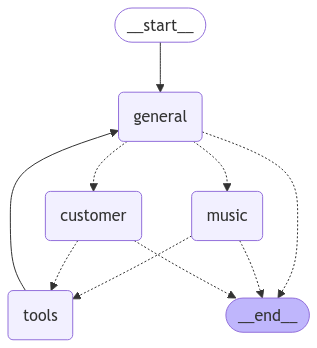

In [188]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## Test it out

In [189]:
from langchain_core.messages import HumanMessage
from langgraph.graph.graph import START

history = []
while True:
    user = input('User (q/Q to quit): ')
    if user in {'q', 'Q'}:
        print('AI: Byebye')
        break
    history.append(HumanMessage(content=user))
    async for output in graph.astream(history):
        if END in output or START in output:
            continue
        # stream() yields dictionaries with output keyed by node name
        for key, value in output.items():
            print(f"Output from node '{key}':")
            print("---")
            print(value)
        print("\n---\n")
    history.append(AIMessage(content=value.content))

/var/folders/xy/yh3smj9111sbf5w7xcdrb6480000gn/T/ipykernel_4228/13706861.py:4: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  _dict = message.dict()


Output from node 'general':
---
content='' additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_ohG6GzghfJ46uFebxKVHyTDr', 'function': {'arguments': '{"choice":"customer"}', 'name': 'Router'}, 'type': 'function'}]} response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4-0125-preview'} name='general' id='run-98e7273a-44af-4aa4-9c3f-146339a5c596-0' tool_calls=[{'name': 'Router', 'args': {'choice': 'customer'}, 'id': 'call_ohG6GzghfJ46uFebxKVHyTDr', 'type': 'tool_call'}]

---



/var/folders/xy/yh3smj9111sbf5w7xcdrb6480000gn/T/ipykernel_4228/13706861.py:4: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  _dict = message.dict()
/var/folders/xy/yh3smj9111sbf5w7xcdrb6480000gn/T/ipykernel_4228/1027942702.py:14: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  ToolInvocation(


Output from node 'customer':
---
content='' additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_jex7p7C2hYBOx2h6TwY6j5sq', 'function': {'arguments': '{"customer_id":1,"updates":{"Company":"xyzcompany"}}', 'name': 'update_customer_info'}, 'type': 'function'}]} response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4-0125-preview'} name='customer' id='run-484a94f8-2fb4-4014-b82a-ba8122d3e5db-0' tool_calls=[{'name': 'update_customer_info', 'args': {'customer_id': 1, 'updates': {'Company': 'xyzcompany'}}, 'id': 'call_jex7p7C2hYBOx2h6TwY6j5sq', 'type': 'tool_call'}]

---

Output from node 'tools':
---
[ToolMessage(content='{\'error\': "Error updating customer info: \'str\' object has no attribute \'rowcount\'"}', id='6ed715a1-f16d-40ea-91cf-aa66bb90ccb4', tool_call_id='call_jex7p7C2hYBOx2h6TwY6j5sq')]

---



/var/folders/xy/yh3smj9111sbf5w7xcdrb6480000gn/T/ipykernel_4228/13706861.py:4: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  _dict = message.dict()


Output from node 'general':
---
content='It seems there was an error while trying to update your information. Could you please try again later or provide more details if you think there might have been a mistake in the request?' additional_kwargs={} response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4-0125-preview'} name='general' id='run-d229ef53-b3fe-4ae5-b604-d9c870b507e6-0'

---

AI: Byebye
